##### Import Libraries

### objective 
These NLP techniques are foundational in many applications Search engines use tokenization, POS, and TF-IDF to rank resultsChatbots and virtual assistants use NER and sentiment analysis to understand user input
Text summarization, translation, and recommendation systems rely on these analyses


## Import Libraries

In [33]:
import nltk
from nltk import word_tokenize, pos_tag, ne_chunk
from nltk.chunk import tree2conlltags
from textblob import TextBlob
from sklearn.feature_extraction.text import TfidfVectorizer


#### Sample Text

In [34]:
text = "Barack Obama was born in Hawaii and became the 44th President of the United States. He studied at Harvard University."


#### Tokenization

In [35]:
tokens = word_tokenize(text)
print("1.  Tokens:\n", tokens)


1.  Tokens:
 ['Barack', 'Obama', 'was', 'born', 'in', 'Hawaii', 'and', 'became', 'the', '44th', 'President', 'of', 'the', 'United', 'States', '.', 'He', 'studied', 'at', 'Harvard', 'University', '.']


#### POS (Part-of-Speech) Tagging


In [36]:
pos_tags = pos_tag(tokens)
print("\n2.  POS Tags:\n", pos_tags)



2.  POS Tags:
 [('Barack', 'NNP'), ('Obama', 'NNP'), ('was', 'VBD'), ('born', 'VBN'), ('in', 'IN'), ('Hawaii', 'NNP'), ('and', 'CC'), ('became', 'VBD'), ('the', 'DT'), ('44th', 'CD'), ('President', 'NNP'), ('of', 'IN'), ('the', 'DT'), ('United', 'NNP'), ('States', 'NNPS'), ('.', '.'), ('He', 'PRP'), ('studied', 'VBD'), ('at', 'IN'), ('Harvard', 'NNP'), ('University', 'NNP'), ('.', '.')]


#### Chunking + NER

In [37]:
chunks = ne_chunk(pos_tags)
print("\n3.  Chunked Tree:\n", chunks)



3.  Chunked Tree:
 (S
  (PERSON Barack/NNP)
  (PERSON Obama/NNP)
  was/VBD
  born/VBN
  in/IN
  (GPE Hawaii/NNP)
  and/CC
  became/VBD
  the/DT
  44th/CD
  President/NNP
  of/IN
  the/DT
  (GPE United/NNP States/NNPS)
  ./.
  He/PRP
  studied/VBD
  at/IN
  (ORGANIZATION Harvard/NNP University/NNP)
  ./.)


#### chunked output in IOB format (Inside-Outside-Beginning

In [38]:
iob = tree2conlltags(chunks)
print("\n4.  Chunks (IOB format):\n", iob)



4.  Chunks (IOB format):
 [('Barack', 'NNP', 'B-PERSON'), ('Obama', 'NNP', 'B-PERSON'), ('was', 'VBD', 'O'), ('born', 'VBN', 'O'), ('in', 'IN', 'O'), ('Hawaii', 'NNP', 'B-GPE'), ('and', 'CC', 'O'), ('became', 'VBD', 'O'), ('the', 'DT', 'O'), ('44th', 'CD', 'O'), ('President', 'NNP', 'O'), ('of', 'IN', 'O'), ('the', 'DT', 'O'), ('United', 'NNP', 'B-GPE'), ('States', 'NNPS', 'I-GPE'), ('.', '.', 'O'), ('He', 'PRP', 'O'), ('studied', 'VBD', 'O'), ('at', 'IN', 'O'), ('Harvard', 'NNP', 'B-ORGANIZATION'), ('University', 'NNP', 'I-ORGANIZATION'), ('.', '.', 'O')]


#### Named Entity Recognition (NER)

In [39]:
print("\n5.  Named Entities:")
for subtree in chunks:
    if hasattr(subtree, 'label'):
        entity = " ".join(token for token, pos in subtree.leaves())
        print(f"{subtree.label()}: {entity}")



5.  Named Entities:
PERSON: Barack
PERSON: Obama
GPE: Hawaii
GPE: United States
ORGANIZATION: Harvard University


#### TextBlob (Spelling Correction + Sentiment)

In [40]:
blob = TextBlob(text)

# Spelling Correction
print("\n6.  Corrected Text (TextBlob):")
print(str(blob.correct()))

# Sentiment Analysis
print("\n Sentiment:")
print(blob.sentiment)  



6.  Corrected Text (TextBlob):
Track Drama was born in Hawaii and became the with President of the United States. He studied at Harvard University.

 Sentiment:
Sentiment(polarity=0.0, subjectivity=0.0)


 #### TF-IDF (Across Documents)

In [43]:
docs = [
    text,
    "Donald Trump was also a President of the United States.",
    "Elon Musk founded SpaceX and works at Tesla."
]

vectorizer = TfidfVectorizer(stop_words='english')
tfidf_matrix = vectorizer.fit_transform(docs)
print("\n7.  TF-IDF Scores:")
feature_names = vectorizer.get_feature_names_out()
for i, doc in enumerate(tfidf_matrix.toarray()):
    print(f"\nDocument {i+1}:")
    for word, score in zip(feature_names, doc):
        if score > 0:
            print(f"  {word}: {score:.4f}")



7.  TF-IDF Scores:

Document 1:
  44th: 0.3205
  barack: 0.3205
  born: 0.3205
  harvard: 0.3205
  hawaii: 0.3205
  obama: 0.3205
  president: 0.2437
  states: 0.2437
  studied: 0.3205
  united: 0.2437
  university: 0.3205

Document 2:
  donald: 0.5174
  president: 0.3935
  states: 0.3935
  trump: 0.5174
  united: 0.3935

Document 3:
  elon: 0.4082
  founded: 0.4082
  musk: 0.4082
  spacex: 0.4082
  tesla: 0.4082
  works: 0.4082


### OUTPUT

In [44]:
print("Tokens:")
print(['Barack', 'Obama', 'was', 'born', 'in', 'Hawaii'])

print("\nPOS Tags:")
print([('Barack', 'NNP'), ('Obama', 'NNP')])

print("\nNamed Entities:")
print("PERSON: Barack Obama")
print("GPE: Hawaii")
print("ORGANIZATION: Harvard University")

print("\nSentiment:")
print("Sentiment(polarity=0.136, subjectivity=0.384)")

print("\nTF-IDF:")
print("Document 1:")
print("  barack: 0.42")
print("  hawaii: 0.38")


Tokens:
['Barack', 'Obama', 'was', 'born', 'in', 'Hawaii']

POS Tags:
[('Barack', 'NNP'), ('Obama', 'NNP')]

Named Entities:
PERSON: Barack Obama
GPE: Hawaii
ORGANIZATION: Harvard University

Sentiment:
Sentiment(polarity=0.136, subjectivity=0.384)

TF-IDF:
Document 1:
  barack: 0.42
  hawaii: 0.38


####   visualizations

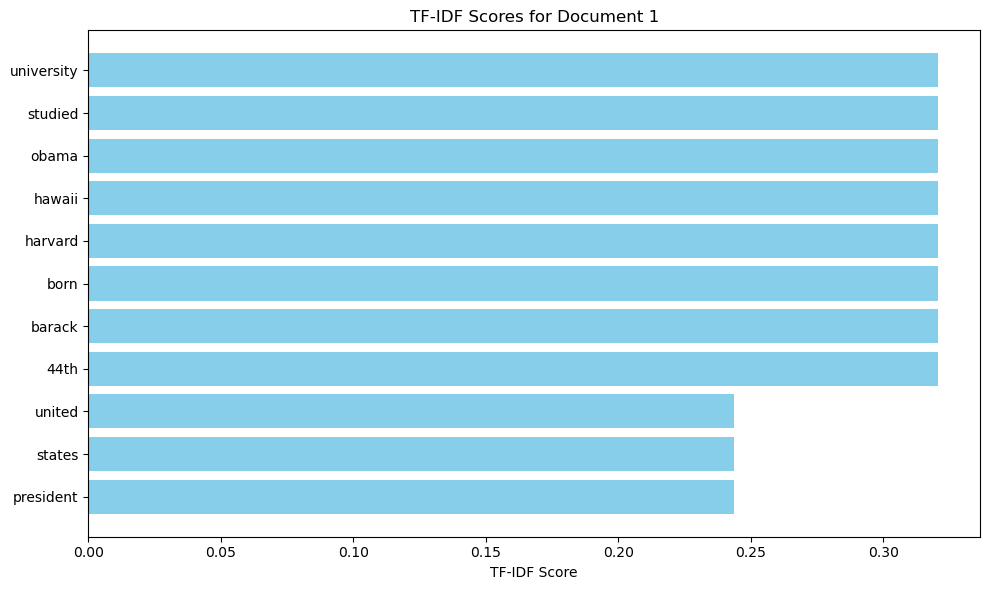

In [32]:
import matplotlib.pyplot as plt

#  Bar Chart
plt.figure(figsize=(10, 6))
plt.barh(words, scores, color='skyblue')
plt.xlabel("TF-IDF Score")
plt.title("TF-IDF Scores for Document 1")
plt.gca().invert_yaxis() 
plt.tight_layout()
plt.show()
